<a href="https://colab.research.google.com/github/srishti-06069/ITA-/blob/main/Smart_Water_leakage.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

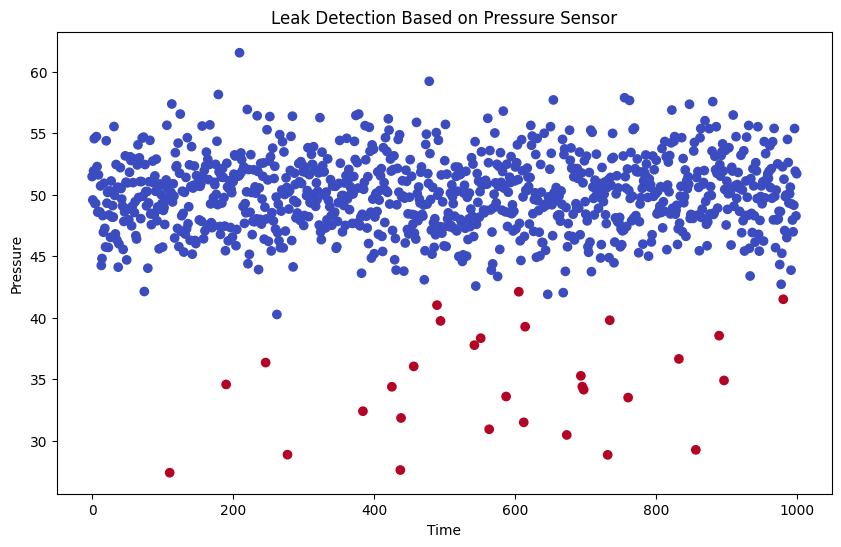

Detected Leak Events:
      pressure    flow_rate  vibration  anomaly
110  27.405022  1204.487508  13.679216        1
190  34.582974  1370.729205   9.657722        1
246  36.362777  1368.432976  11.117269        1
277  28.873801  1302.300395   9.583387        1
384  32.406880  1316.156632  12.189306        1
Total leaks detected: 30


In [ ]:
# Smart Water Leakage Detection System
# Simulated IoT Sensor Data + Machine Learning

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

# -------------------------------
# 1. Generate Simulated Sensor Data
# -------------------------------

np.random.seed(42)

n_samples = 1000

# Normal pipeline behavior
pressure = np.random.normal(loc=50, scale=3, size=n_samples)
flow_rate = np.random.normal(loc=1000, scale=50, size=n_samples)
vibration = np.random.normal(loc=5, scale=1, size=n_samples)

# Create dataframe
data = pd.DataFrame({
    "pressure": pressure,
    "flow_rate": flow_rate,
    "vibration": vibration
})

# Introduce leak anomalies
anomaly_indices = np.random.choice(n_samples, 30)

data.loc[anomaly_indices, "pressure"] -= np.random.uniform(10,20,30)
data.loc[anomaly_indices, "flow_rate"] += np.random.uniform(200,400,30)
data.loc[anomaly_indices, "vibration"] += np.random.uniform(5,10,30)


scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)

model = IsolationForest(contamination=0.03)
data["anomaly"] = model.fit_predict(scaled_data)

# Convert anomaly labels
data["anomaly"] = data["anomaly"].map({1:0, -1:1})


plt.figure(figsize=(10,6))

plt.scatter(data.index, data["pressure"],
            c=data["anomaly"], cmap="coolwarm")

plt.title("Leak Detection Based on Pressure Sensor")
plt.xlabel("Time")
plt.ylabel("Pressure")
plt.show()


leaks = data[data["anomaly"] == 1]

print("Detected Leak Events:")
print(leaks.head())

print("Total leaks detected:", len(leaks))